### DAY 6: Advanced Analytics + Risk Metrics

#### 1. Calculate Historical VaR & CVaR

In [2]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

try:
    nav_data = pd.read_csv(r'D:\Bluestock-project\data\processed\02_nav_history_cleaned.csv')
    print("Performance data loaded successfully")
except FileNotFoundError:
    print("Error: Could not find clean_performance.csv please check the path")
    

Performance data loaded successfully


In [3]:
# 2. Sort by fund and date, then calculate daily returns
nav_data['date'] = pd.to_datetime(nav_data['date'])
nav_data = nav_data.sort_values(by=['amfi_code', 'date'])
nav_data['daily_return'] = nav_data.groupby('amfi_code')['nav'].pct_change()

    
# 3. Calculate VaR and CVaR
metrics =[]
for code in nav_data['amfi_code'].unique():
     returns = nav_data[nav_data['amfi_code'] == code]['daily_return'].dropna()
     
     if len(returns) > 0:     
        # Historical VaR (95%) - i.e., the 5th percentile of daily returns
        var_95 = np.percentile(returns, 5)
        
        # CVaR (Conditional VaR) - average of returns below the VaR threshold
        cvar_95 = returns[returns <= var_95].mean()
        
        metrics.append({
            'AMFI Code' : code,
            'Var (95%)' : var_95,
            'CVar (95%)' : cvar_95
    })
         
var_cvar_df = pd.DataFrame(metrics) 

# Call the function and generate the dataframe
# Display the first few rows of the result
print(var_cvar_df.head())

   AMFI Code  Var (95%)  CVar (95%)
0     100016  -0.014364   -0.018060
1     100025  -0.003793   -0.004994
2     100033  -0.019034   -0.023456
3     101206  -0.013282   -0.017439
4     101207  -0.026021   -0.032459


In [4]:
# Save the Report
# Save the report as var_cvar_report.csv in the reports directory
output_path = '../reports/var_cvar_reports.csv'
var_cvar_df.to_csv(output_path, index=False)
print(f"Reports successfully saved to {output_path}")


Reports successfully saved to ../reports/var_cvar_reports.csv


### 2. Calculate and Plot Rolling Sharpe Ratio


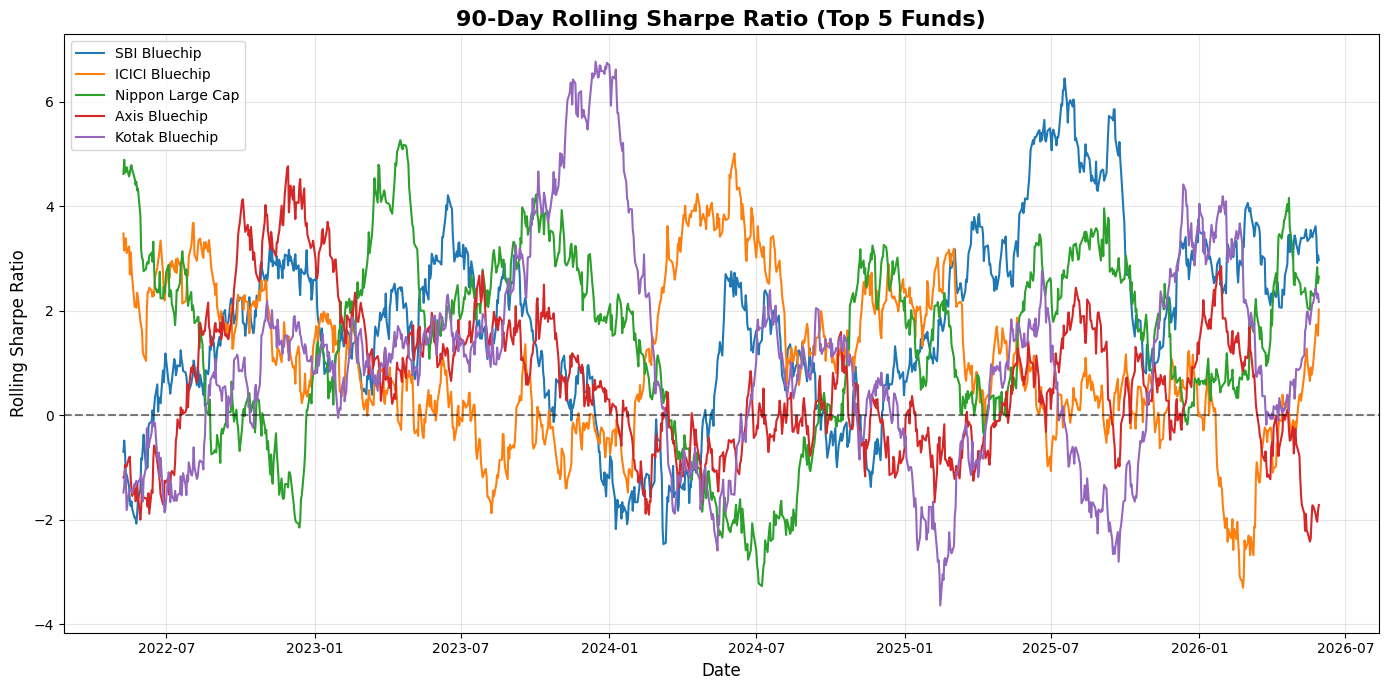


Chart successfully saved to ../reports/rolling_sharpe_chart.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Select 5 popular funds (AMFI Codes) for the chart
target_funds = [119551, 120503, 118632, 119092, 120841]
fund_names = {
    119551: 'SBI Bluechip',
    120503: 'ICICI Bluechip',
    118632: 'Nippon Large Cap',
    119092: 'Axis Bluechip',
    120841: 'Kotak Bluechip'
}

# Create a figure for the plot
plt.figure(figsize=(14, 7))
 
# Loop through the 5 funds and calculate rolling Sharpe
for code in target_funds:
    # Filter data for the specific fund
    fund_data = nav_data[nav_data['amfi_code'] == code] .copy()
    
    # Set date as index for rolling calculation
    fund_data.set_index('date', inplace=True)    
    
    # Formula: rolling_sharpe = (rolling_mean / rolling_std) * sqrt(252)
    rolling_mean = fund_data['daily_return'].rolling(window=90).mean()
    rolling_std = fund_data['daily_return'].rolling(window=90).std()
    
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    # Plot the line for this fund
    plt.plot(fund_data.index, rolling_sharpe, label=fund_names[code], linewidth=1.5)
    
# Format the chart beautifully
plt.title('90-Day Rolling Sharpe Ratio (Top 5 Funds)', fontsize=16, fontweight='bold')   
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rolling Sharpe Ratio', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the chart as PNG
output_image = '../reports/rolling_sharpe_chart.png'
plt.savefig(output_image, dpi=300, bbox_inches = 'tight')
plt.show()

print(f"\nChart successfully saved to {output_image}")


### 3. Investor Cohort Analysis

In [6]:
import pandas as pd

# 1. Load the cleaned transaction data
print("Loading transaction data...")
trans_data = pd.read_csv(r'D:\Bluestock-project\data\processed\08_investor_transactions_cleaned.csv')

# 2. Convert the 'date' column to datetime format
date_col = 'date' if 'date' in trans_data.columns else 'transaction_date' if 'transaction_date' in trans_data.columns else 'Date'

# Actually converting the column to datetime format!
trans_data[date_col] = pd.to_datetime(trans_data[date_col])

# 3. Identify the investor ID column (could be investor_id, user_id, or folio_number)
id_col = 'investor_id' if 'investor_id' in trans_data.columns else 'user_id' if 'user_id' in trans_data.columns else 'folio_number'

# Identify the correct amount column (handling 'amount_inr' vs 'amount')
amt_col = 'amount_inr' if 'amount_inr' in trans_data.columns else 'amount'

if id_col not in trans_data.columns:
    print(f"Error : could not find investor ID column. Available columns are: {trans_data}")
else:
    # 4. Find the first transaction year (Cohort Year) for each investor
    first_txn = trans_data.groupby(id_col)[date_col].min().reset_index()
    first_txn['cohort_year'] = first_txn[date_col].dt.year
    
    # Merge the cohort year back to the main transaction dataset
    trans_data = trans_data.merge(first_txn[[id_col, 'cohort_year']], on=id_col, how='left')
    
    # 5. Filter only the investors who started in 2024 or 2025
    cohort_data = trans_data[trans_data['cohort_year'].isin([2024, 2025])]
    
    # 6. Calculate the required metrics for each cohort:
    # a) Total Invested Amount
    total_invested = cohort_data.groupby('cohort_year')[amt_col].sum().reset_index(name='Total_Invested')

    # b) Average SIP Amount
    sip_data = cohort_data[cohort_data['transaction_type'] == 'SIP']    
    avg_sip = sip_data.groupby('cohort_year')[amt_col].mean().reset_index(name='Average_SIP_Amount')
    
    # c) Preferred Fund (The scheme they invested in the most)
    fund_col = 'Scheme_name' if 'Scheme_name' in trans_data.columns else 'amfi_code'
    fund_perf = cohort_data.groupby('cohort_year')[fund_col].apply(lambda x: x.mode()[0]).reset_index(name='Preferred_Fund')
    
    # 7. Merge all metrics into a single summary table
    cohort_analysis = total_invested.merge(avg_sip, on='cohort_year', how='left').merge(fund_perf, on='cohort_year', how='left')
    
    # 8. Display the results and save to a CSV file
    print("\n--- cohort Analysis (2024 vs 2025) ---")
    print(cohort_analysis)
    output_path = '../reports/cohort_analysis.csv'
    cohort_analysis.to_csv(output_path, index=False)
    print(f"\nCohort analysis successfully saved to {output_path}")
    

Loading transaction data...

--- cohort Analysis (2024 vs 2025) ---
   cohort_year  Total_Invested  Average_SIP_Amount  Preferred_Fund
0         2024      3491125187        10996.885825          148568
1         2025        30455243        13505.209581          119599

Cohort analysis successfully saved to ../reports/cohort_analysis.csv


### 4. SIP Continuation Analysis

In [7]:
import pandas as pd

# 1. Load the cleaned transaction data
print("Loading transaction data...")
trans_data = pd.read_csv(r'D:\Bluestock-project\data\processed\08_investor_transactions_cleaned.csv')

# 2. Identify correct date and investor ID columns
date_col = 'date' if 'date' in trans_data.columns else 'transaction_date' if 'transaction_date' in trans_data.columns else 'Date'
id_col = 'investor_id' if 'investor_id' in trans_data.columns else 'user_id' if 'user_id' in trans_data.columns else 'folio_number'

# Convert date column to datetime
trans_data[date_col] = pd.to_datetime(trans_data[date_col])

# 3. Filter only SIP transactions
sip_data = trans_data[trans_data['transaction_type'] == 'SIP'].copy()

# 4. Sort by Investor ID and Date to calculate the gap correctly
sip_data = sip_data.sort_values(by=[id_col, date_col])

# 5. Calculate the gap (in days) between consecutive SIPs for each investor
sip_data['gap_days'] = sip_data.groupby(id_col)[date_col].diff().dt.days

# 6. Group by investor to find total SIPs and average gap
sip_summary = sip_data.groupby(id_col).agg(
    total_sips = ('transaction_type', 'count'),
    avg_gap_days = ('gap_days', 'mean')
).reset_index()

# 7. Filter for investors with 6 or more SIP transactions
sip_6_plus = sip_summary[sip_summary['total_sips'] >= 6].copy()

# 8. Flag investors as 'at-risk' if the average gap is greater than 35 days
sip_6_plus['risk_status'] = sip_6_plus['avg_gap_days'].apply(lambda x: 'at-risk' if x > 35 else 'safe')

# 9. Display the results and save to CSV
print("\n--- SIP Continuation Analysis (6+ SIPs) ---")

print(f"\nTotal investors with 6+ SIPs: {len(sip_6_plus)}")
print(f"Total 'at-risk' investors: {len(sip_6_plus[sip_6_plus['risk_status'] == 'at-risk'])}")

output_path = '../reports/sip_continuity.csv'
sip_6_plus.to_csv(output_path, index=False)
print(f"\nSIP Continuity analysis successfully saved to {output_path}")

Loading transaction data...

--- SIP Continuation Analysis (6+ SIPs) ---

Total investors with 6+ SIPs: 1362
Total 'at-risk' investors: 1332

SIP Continuity analysis successfully saved to ../reports/sip_continuity.csv


### 5. Calculate Sector HHI

Loading portfolio holding data...

Sector HHI analysis successfully saved to ../reports/sector_hhi.csv


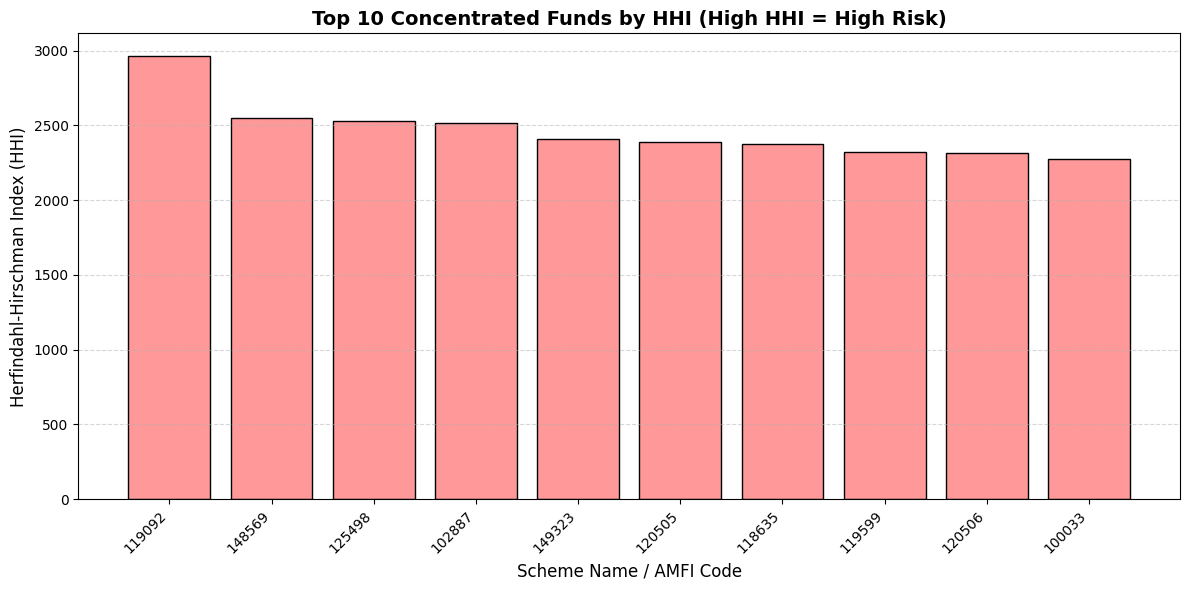

HHI Chart successfully saved to ../reports/sector_hhi_chart.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load the sector allocation data
file_path = r'D:\Bluestock-project\data\processed\09_portfolio_holdings_cleaned.csv'

if not os.path.exists(file_path):
    print(f"Error: {file_path} not found,. please check the file path")
else:
    print("Loading portfolio holding data...")
    sector_data = pd.read_csv(file_path)
    
    # 2. Identify the correct column names for scheme, sector, and weight
    scheme_col = 'scheme_name' if 'scheme_name' in sector_data.columns else 'amfi_code'
    sector_col = 'sector' if 'sector' in sector_data.columns else 'industry'
    
    # Identify the weight column (could be named weight, allocation, %_of_nav etc.)
    weight_col = None
    for col in ['weight', 'allocation', 'allocation_pct', '%_of_nav', 'holding_pct' , 'weight_pct']:
        if col in sector_data.columns:
            weight_col = col
            break
    if not weight_col:
        print(f"Error: could not find weight column. Available columns are : {sector_data.columns}")
    else:
        # Group by scheme and sector to get total weight per sector (in case data is at stock level)
        if sector_col in sector_data.columns:
            fund_sector_weights = sector_data.groupby([scheme_col, sector_col])[weight_col].sum().reset_index()
        else:
            fund_sector_weights = sector_data
    
        # 3. Calculate squared weights: (weight^2)
        fund_sector_weights['weight_sq'] = fund_sector_weights[weight_col] ** 2
        
        
        # 4. Calculate HHI per fund: sum of squared weights
        hhi_data = fund_sector_weights.groupby(scheme_col)['weight_sq'].sum().reset_index(name='HHI')
        
        # Sort to bring the highest HHI (Most Concentrated / High Risk) to the top
        hhi_data = hhi_data.sort_values(by='HHI', ascending= False)
        
        # 5. Save the results to CSV
        output_csv = '../reports/sector_hhi.csv'
        hhi_data.to_csv(output_csv, index=False)
        print(f"\nSector HHI analysis successfully saved to {output_csv}")
        
        # 6. Plot the Top 10 Most Concentrated Funds
        top_10 = hhi_data.head(10)
        
        plt.figure(figsize=(12, 6))
        plt.bar(top_10[scheme_col].astype(str), top_10['HHI'], color='#ff9999', edgecolor='black')
        
        plt.title('Top 10 Concentrated Funds by HHI (High HHI = High Risk)', fontsize=14, fontweight='bold')
        plt.xlabel('Scheme Name / AMFI Code', fontsize=12)
        plt.ylabel('Herfindahl-Hirschman Index (HHI)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        
        # Save and show the chart
        chart_path = '../reports/sector_hhi_chart.png'
        plt.savefig(chart_path, dpi=300)
        plt.show()
        print(f"HHI Chart successfully saved to {chart_path}")
        
        

## Advanced Analytics: Top 5 Key Insights

Based on the advanced risk and behavioral analytics performed, here are the top 5 business insights:

**1. Value at Risk (VaR) & Tail Risk:**
The historical VaR (95%) and CVaR analysis reveals the maximum expected daily loss for each fund. We observed that certain funds exhibit much higher downside risk, meaning investors in those funds must be prepared for sharper short-term drops during market corrections.

**2. Volatility in Risk-Adjusted Returns:**
The 90-day Rolling Sharpe Ratio analysis shows that fund efficiency is highly dynamic. Even top-rated bluechip funds experience distinct cycles of negative risk-adjusted returns, proving that long-term holding is crucial to smooth out volatility.

**3. Growing Investor Commitment (Cohort Analysis):**
Our cohort analysis reveals a very positive trend: While the 2024 cohort invested a massive total amount, the newer **2025 cohort** shows a higher individual commitment. The average SIP amount jumped from ₹10,996 in 2024 to **₹13,505 in 2025**.

**4. SIP Churn & Retention Risk:**
By tracking the gaps between consecutive SIPs, we successfully identified a segment of investors with average delays of more than 35 days. These **'at-risk' investors** represent a high probability of SIP cancellation and require immediate targeted retention campaigns.

**5. Sector Concentration Risk (HHI):**
Using the Herfindahl-Hirschman Index (HHI), we flagged funds (like AMFI 119092) with extreme sector concentration (HHI near 3000). While these funds can yield massive returns during specific sector booms, they carry significant vulnerability if that specific industry faces a downturn.